In [52]:
# run in a cell (you may need to install gmsh and meshio if not present)
# !pip install gmsh==4.11.0 meshio scipy matplotlib numpy

import gmsh
import meshio
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# nicer plotting defaults
plt.rcParams.update({'figure.figsize': (8,6), 'font.size': 12})


In [53]:
# Parameters (example geometry -- modify to your cavity)
# We'll create a rectangular cavity  length (along z) x radius (along r)
length = 0.1   # meters (z-direction)
radius = 0.15   # meters (r-direction)
mesh_size = radius/50  # target element size
c = 299792458.0

In [54]:
#Actual TM010 freq

f = (c/np.pi)*2.405/radius
f/1e6

1530.0113477286461

In [55]:
# Initialize gmsh
gmsh.initialize()
gmsh.model.add("axisymmetric_cavity")


# Points (z, r)
p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0, mesh_size)   # axis corner (z=0,r=0)
p2 = gmsh.model.geo.addPoint(length, 0.0, 0, mesh_size) # axis top (z=length,r=0)
p3 = gmsh.model.geo.addPoint(length, radius, 0, mesh_size)
p4 = gmsh.model.geo.addPoint(0.0, radius, 0, mesh_size)

# Lines (edges of the 2D profile)
l1 = gmsh.model.geo.addLine(p1, p2)  # axis line (r=0)
l2 = gmsh.model.geo.addLine(p2, p3)
l3 = gmsh.model.geo.addLine(p3, p4)
l4 = gmsh.model.geo.addLine(p4, p1)

# Curve loop and plane surface
cl = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
surf = gmsh.model.geo.addPlaneSurface([cl])

# Physical groups (for BCs)
gmsh.model.geo.addPhysicalGroup(1, [l1], tag=1)  # axis line
gmsh.model.geo.addPhysicalGroup(1, [l2, l3, l4], tag=2)  # cavity walls
gmsh.model.geo.addPhysicalGroup(2, [surf], tag=3)  # interior surface

# Synchronize and mesh
gmsh.model.geo.synchronize()
gmsh.model.mesh.generate(2)

# write mesh to file for meshio to read
msh_filename = "cavity.msh"
gmsh.write(msh_filename)
gmsh.finalize()

# read with meshio


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000433334s, CPU 0.000173s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0311083s, CPU 0.028787s)
Info    : 2064 nodes 4130 elements
Info    : Writing 'cavity.msh'...
Info    : Done writing 'cavity.msh'


In [56]:
mesh = meshio.read(msh_filename)
points = mesh.points[:, :2].copy()   # (z,r)
cells = None
for cb in mesh.cells:
    if cb.type == "triangle":
        cells = cb.data.copy()
        break
if cells is None:
    raise RuntimeError("No triangles found in mesh.")

print("Mesh: nodes =", points.shape[0], "triangles =", cells.shape[0])

# --- start from your variables ---
# mesh = meshio.read('/path/to/ell_shape_new.msh')
# points = mesh.points[:, :2].copy()
# cells = ... (triangle block)
n_points = points.shape[0]

# mapping tag -> name if available
tag_to_name = {}
if getattr(mesh, "field_data", None):
    for name, arr in mesh.field_data.items():
        # arr usually [dim, tag] or [tag]
        tag = int(arr[1]) if len(arr) > 1 else int(arr[0])
        tag_to_name[tag] = name

# prepare outputs
is_on_boundary = np.zeros(n_points, dtype=bool)
# For storing physical group names per node (set because node may be in multiple groups)
node_phys_names = [set() for _ in range(n_points)]

# helper to attach a physical tag -> name to a node
def attach_tag_to_node(node_idx, tag):
    if tag is None:
        return
    try:
        tag_int = int(tag)
    except:
        return
    name = tag_to_name.get(tag_int, None)
    if name is not None:
        node_phys_names[node_idx].add(name)
    else:
        # fallback: store tag string if name not available
        node_phys_names[node_idx].add(f"tag_{tag_int}")

# 1) Check for explicit vertex / point cell blocks (0D)
vertex_types = {"vertex", "point", "points"}
found_any = False
for idx, cb in enumerate(mesh.cells):
    ctype = cb.type.lower()
    if ctype in vertex_types:
        found_any = True
        node_indices = cb.data.flatten()
        # corresponding cell_data arrays (if present) are in mesh.cell_data["gmsh:physical"]
        phys_blocks = mesh.cell_data.get("gmsh:physical", None)
        phys_for_block = None
        if phys_blocks is not None and idx < len(phys_blocks):
            phys_for_block = phys_blocks[idx]
        for i, node in enumerate(node_indices):
            is_on_boundary[int(node)] = True
            if phys_for_block is not None:
                tag = phys_for_block[i]
                attach_tag_to_node(int(node), tag)

# 2) Check for explicit 1D boundary elements (lines / segments)
one_d_types = {"line", "line3", "segment", "bar", "edge"}
found_1d = False
for idx, cb in enumerate(mesh.cells):
    ctype = cb.type.lower()
    if ctype in one_d_types:
        found_1d = True
        edges = cb.data  # shape (m, 2) or (m, 3) for higher-order; take first two nodes for topology
        phys_blocks = mesh.cell_data.get("gmsh:physical", None)
        phys_for_block = phys_blocks[idx] if (phys_blocks is not None and idx < len(phys_blocks)) else None
        for j, ent in enumerate(edges):
            # some line element types may be shape (m,2) or (m,3) (with mid nodes); take unique endpoints
            # endpoints = (ent[0], ent[-1]) to be robust
            n0 = int(ent[0]); n1 = int(ent[-1])
            is_on_boundary[n0] = True
            is_on_boundary[n1] = True
            if phys_for_block is not None:
                tag = phys_for_block[j]
                attach_tag_to_node(n0, tag)
                attach_tag_to_node(n1, tag)

# 3) Fallback: if no explicit 1D or vertex blocks, find boundary from triangle connectivity
if not found_any and not found_1d:
    # build edge counts from triangles
    # triangles are in `cells` variable you already extracted (Ntri x 3)
    tri = cells.astype(np.int64)
    # produce canonical ordered edges (min,max) for counting
    e01 = np.vstack([tri[:,0], tri[:,1]]).T
    e12 = np.vstack([tri[:,1], tri[:,2]]).T
    e20 = np.vstack([tri[:,2], tri[:,0]]).T
    all_edges = np.vstack([e01, e12, e20])
    # canonicalize
    mins = np.minimum(all_edges[:,0], all_edges[:,1])
    maxs = np.maximum(all_edges[:,0], all_edges[:,1])
    can_edges = np.vstack([mins, maxs]).T
    # count unique edges
    # view as structured to use numpy unique
    dtype = np.dtype([('a', can_edges.dtype), ('b', can_edges.dtype)])
    can_edges_view = can_edges.view(dtype)
    uniq, counts = np.unique(can_edges_view, return_counts=True)
    # edges that appear once are boundary edges
    boundary_mask = counts == 1
    boundary_edges = np.vstack([uniq['a'][boundary_mask], uniq['b'][boundary_mask]]).T
    # mark nodes on these edges
    for e in boundary_edges:
        n0, n1 = int(e[0]), int(e[1])
        is_on_boundary[n0] = True
        is_on_boundary[n1] = True
    # Note: triangle-only meshes rarely contain gmsh:physical tags for edges in meshio output.
    # If the original .msh had physical groups for boundary lines but meshio didn't write line cells,
    # prefer reading via the gmsh Python API for robust retrieval of physical point groups.

# summary
num_boundary = int(is_on_boundary.sum())
print(f"Total points: {n_points}; boundary points: {num_boundary}")

# optional: create an integer mask (0/1) or indices
boundary_indices = np.nonzero(is_on_boundary)[0]
boundary_mask_int = is_on_boundary.astype(np.uint8)  # 1 for boundary, 0 otherwise

# show a small sample of boundary nodes with any physical names found
sample_show = 20
print("Sample boundary indices (first {}): {}".format(sample_show, boundary_indices[:sample_show].tolist()))
# show names for a few (if any)
named = [(i, sorted(list(node_phys_names[i]))) for i in boundary_indices if node_phys_names[i]]
print("Boundary nodes with physical names (up to 20):", named[:20])

# Now you have:
# - is_on_boundary (bool array)
# - boundary_mask_int (0/1 uint8 array)
# - boundary_indices (list of indices)
# - node_phys_names (list of sets of names for each node)


Mesh: nodes = 2064 triangles = 3958
Total points: 2064; boundary points: 168
Sample boundary indices (first 20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Boundary nodes with physical names (up to 20): [(np.int64(0), ['tag_1', 'tag_2']), (np.int64(1), ['tag_1', 'tag_2']), (np.int64(2), ['tag_2']), (np.int64(3), ['tag_2']), (np.int64(4), ['tag_1']), (np.int64(5), ['tag_1']), (np.int64(6), ['tag_1']), (np.int64(7), ['tag_1']), (np.int64(8), ['tag_1']), (np.int64(9), ['tag_1']), (np.int64(10), ['tag_1']), (np.int64(11), ['tag_1']), (np.int64(12), ['tag_1']), (np.int64(13), ['tag_1']), (np.int64(14), ['tag_1']), (np.int64(15), ['tag_1']), (np.int64(16), ['tag_1']), (np.int64(17), ['tag_1']), (np.int64(18), ['tag_1']), (np.int64(19), ['tag_1'])]


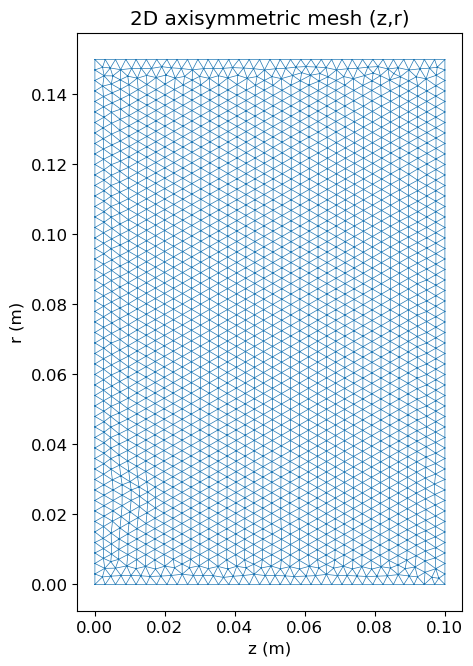

In [ ]:
# quick mesh plot
plt.figure(figsize=(50*length,50*radius))
plt.triplot(points[:,0], points[:,1], cells, lw=0.5)
plt.gca().set_aspect('equal')

plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.title('2D axisymmetric mesh (z,r)')
plt.show()


In [62]:
cells.shape

(3958, 3)